# Bluesky IP Overlap

Explore which Bluesky authors post about more than one IP, and how strongly each pair of IPs shares an audience. Assumes `uv run python src/build_bluesky_tables.py --run-dir data/raw/bluesky_runs/<run>` and `uv run python src/load_duckdb.py` have been run so the `bluesky_*` views exist.

In [1]:
from pathlib import Path

import duckdb
import polars as pl
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = ROOT / "data" / "duckdb" / "fandom.duckdb"

con = duckdb.connect(str(DB_PATH), read_only=True)


def q(sql: str) -> pl.DataFrame:
    return con.sql(sql).pl()


print({"db_path": str(DB_PATH), "exists": DB_PATH.exists()})

{'db_path': '/home/dmika/code/fandom-project/data/duckdb/fandom.duckdb', 'exists': True}


## Users posting across multiple IPs

Aggregate `bluesky_user_ip_activity` per `author_did` and keep only users that show up in more than one IP.

In [2]:
user_ip_overlap = q("""
with per_user as (
    select
        author_did,
        any_value(author_handle) as author_handle,
        any_value(author_display_name) as author_display_name,
        count(distinct ip_name) as unique_ips,
        sum(total_posts) as total_posts,
        list(distinct ip_name order by ip_name) as ips
    from bluesky_user_ip_activity
    group by author_did
)
select *
from per_user
where unique_ips > 1
order by unique_ips desc, total_posts desc
""")

print("multi-IP authors:", user_ip_overlap.height)
user_ip_overlap.head(20)

multi-IP authors: 2083


author_did,author_handle,author_display_name,unique_ips,total_posts,ips
str,str,str,i64,"decimal[38,0]",list[str]
"""did:plc:m2yuqynl2cttvi4k5453ye…","""feed.igeek.gamer-geek-news.com…","""input""",6,82,"[""Dungeons & Dragons"", ""Harry Potter"", … ""Warhammer 40K""]"
"""did:plc:2klas4fif3tt2h2yth33sp…","""gamesradarplus.bsky.social""","""GamesRadar+""",6,56,"[""Dungeons & Dragons"", ""Harry Potter"", … ""Warhammer 40K""]"
"""did:plc:zwxl6dnun52q3ywiao2ad3…","""flipboardbr.flipboard.com.ap.b…","""Flipboard Brasil""",6,45,"[""Dungeons & Dragons"", ""Harry Potter"", … ""Warhammer 40K""]"
"""did:plc:xwqgusybtrpm67tcwqdfmz…","""ign.com""","""IGN""",6,41,"[""Dungeons & Dragons"", ""Harry Potter"", … ""Warhammer 40K""]"
"""did:plc:6w7425hsc4mjjkte2mbsxd…","""uk-nb.bsky.social""","""""",6,36,"[""Dungeons & Dragons"", ""Harry Potter"", … ""Warhammer 40K""]"
…,…,…,…,…,…
"""did:plc:nku6hqfdohkbyoxsik2kso…","""dragoncobolt.bsky.social""","""Dragon Cobolt""",5,36,"[""Dungeons & Dragons"", ""Harry Potter"", … ""Warhammer 40K""]"
"""did:plc:c4tbxxsay3scrkidq3adyw…","""thehobbyhub.bsky.social""","""The Hobby Hub""",5,35,"[""Harry Potter"", ""Marvel"", … ""Warhammer 40K""]"
"""did:plc:bveezgbr3omaazsltkc2ad…","""cheapassgamer.com""","""Cheap Ass Gamer""",5,29,"[""Dungeons & Dragons"", ""Harry Potter"", … ""Star Wars""]"


## How many IPs do users post about?

Bucket every author by the number of distinct IPs they posted under.

In [3]:
ip_count_distribution = q("""
with per_user as (
    select author_did, count(distinct ip_name) as unique_ips
    from bluesky_user_ip_activity
    group by author_did
)
select unique_ips, count(*) as n_authors
from per_user
group by unique_ips
order by unique_ips
""")

ip_count_distribution

unique_ips,n_authors
i64,i64
1,21273
2,1715
3,279
4,66
5,15
6,8


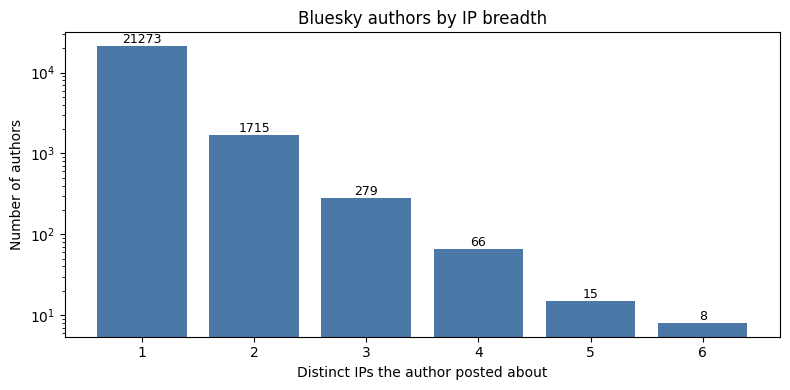

In [4]:
dist_pd = ip_count_distribution.to_pandas()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dist_pd["unique_ips"], dist_pd["n_authors"], color="#4c78a8")
ax.set_xlabel("Distinct IPs the author posted about")
ax.set_ylabel("Number of authors")
ax.set_title("Bluesky authors by IP breadth")
ax.set_yscale("log")
for x, y in zip(dist_pd["unique_ips"], dist_pd["n_authors"]):
    ax.text(x, y, str(y), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## Jaccard overlap between IP pairs

For each ordered IP pair `(ip_a, ip_b)` count shared authors and compute Jaccard = `|A ∩ B| / |A ∪ B|`.

In [7]:
jaccard_pairs = q("""
with ip_users as (
    select distinct ip_name, author_did
    from bluesky_user_ip_activity
    where author_did is not null
),
ip_sizes as (
    select ip_name, count(*) as n_users
    from ip_users
    group by ip_name
),
pair_intersection as (
    select
        a.ip_name as ip_a,
        b.ip_name as ip_b,
        count(*) as overlap_n
    from ip_users a
    join ip_users b
      on a.author_did = b.author_did
     and a.ip_name < b.ip_name
    group by a.ip_name, b.ip_name
)
select
    p.ip_a,
    p.ip_b,
    p.overlap_n,
    sa.n_users as users_a,
    sb.n_users as users_b,
    p.overlap_n * 1.0 / (sa.n_users + sb.n_users - p.overlap_n) as jaccard
from pair_intersection p
join ip_sizes sa on sa.ip_name = p.ip_a
join ip_sizes sb on sb.ip_name = p.ip_b
order by jaccard desc
""")

jaccard_pairs

ip_a,ip_b,overlap_n,users_a,users_b,jaccard
str,str,i64,i64,i64,f64
"""Marvel""","""Star Wars""",833,5532,5958,0.078165
"""Harry Potter""","""Star Wars""",276,3056,5958,0.031586
"""Harry Potter""","""Marvel""",248,3056,5532,0.029736
"""Dungeons & Dragons""","""Star Wars""",277,5051,5958,0.025811
"""Star Wars""","""Warhammer 40K""",211,5958,3299,0.023325
…,…,…,…,…,…
"""Harry Potter""","""Pokemon""",95,3056,3031,0.015854
"""Dungeons & Dragons""","""Harry Potter""",125,5051,3056,0.01566
"""Dungeons & Dragons""","""Pokemon""",111,5051,3031,0.013925


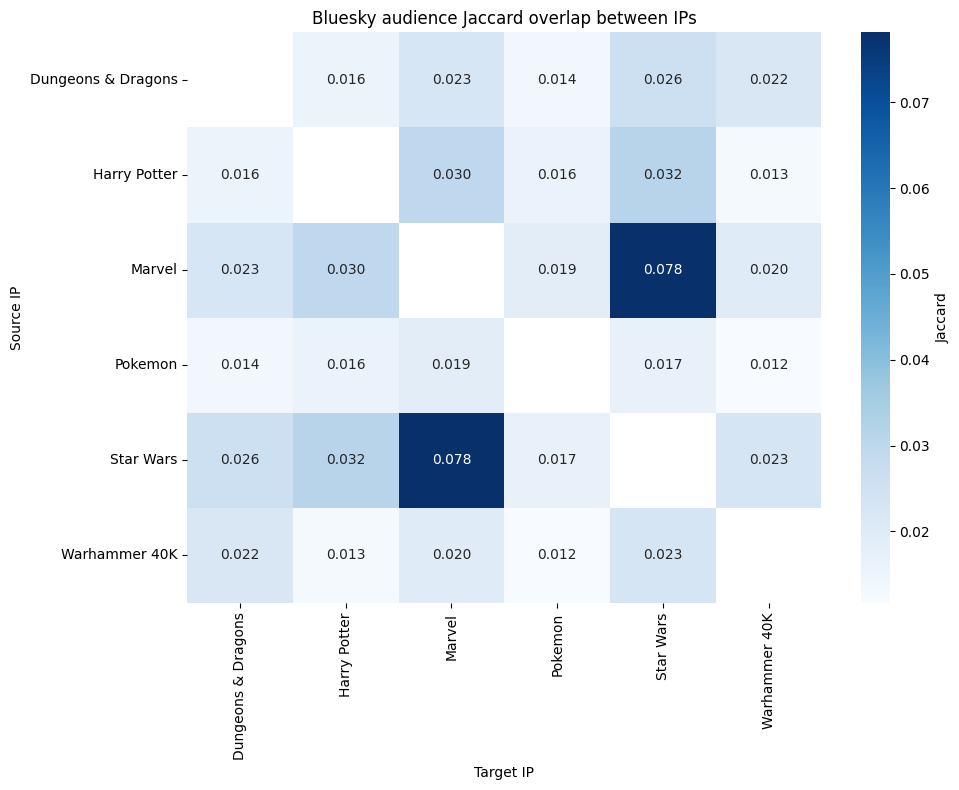

: 

In [ ]:
import numpy as np
import seaborn as sns

ip_order = sorted(
    set(jaccard_pairs["ip_a"].to_list()) | set(jaccard_pairs["ip_b"].to_list())
)
index_by_ip = {name: i for i, name in enumerate(ip_order)}

matrix = np.full((len(ip_order), len(ip_order)), np.nan)
for row in jaccard_pairs.iter_rows(named=True):
    i = index_by_ip[row["ip_a"]]
    j = index_by_ip[row["ip_b"]]
    matrix[i, j] = row["jaccard"]
    matrix[j, i] = row["jaccard"]

heatmap_pd = (
    pl.DataFrame(matrix, schema=ip_order)
    .with_columns(pl.Series("source_ip", ip_order))
    .to_pandas()
    .set_index("source_ip")
    .loc[ip_order, ip_order]
)
heatmap_pd.index.name = "Source IP"
heatmap_pd.columns.name = "Target IP"

mask = np.eye(len(ip_order), dtype=bool)

plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_pd,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    mask=mask,
    cbar_kws={"label": "Jaccard"},
)
plt.title("Bluesky audience Jaccard overlap between IPs")
plt.xlabel("Target IP")
plt.ylabel("Source IP")
plt.tight_layout()
plt.show()

In [ ]:
con.close()